In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import plotly.express as px

In [2]:
import openpyxl

In [3]:
df=pd.read_excel(r"C:\Users\fayaz\Downloads\HR_Employee_Performance_Dataset.xlsx")

In [4]:
df.head()

,Employee ID,Employee Name,Department,Job Role,Joining Date,Experience (Years),Age,Gender,Work Location,Working Hours (Per Week),Performance Rating,Salary ($),Bonus ($),Training Hours (Per Year),Job Satisfaction Score,Leave Days Taken,Remote Work (%),Promotion Status
0,EMP0001,Employee 463,Sales,Sales Executive,2018-11-21,5.1,48,Female,San Francisco,40,3,4707.36,2923.73,34,3,15,3,Yes
1,EMP0002,Employee 56,Sales,Account Manager,2018-07-13,5.5,22,Female,New York,45,2,10320.90,3705.78,59,7,16,92,Yes
2,EMP0003,Employee 118,Operations,Supply Chain Analyst,2017-07-09,6.5,59,Other,Austin,34,2,11440.51,1671.09,80,1,17,40,No
3,EMP0004,Employee 289,HR,HR Manager,2017-10-16,6.2,37,Other,Austin,40,3,7664.84,1570.55,84,2,9,36,Yes
4,EMP0005,Employee 128,HR,HR Executive,2023-10-11,0.2,24,Male,Chicago,35,5,8464.95,3978.74,70,4,8,64,Yes


In [5]:
df.tail()

,Employee ID,Employee Name,Department,Job Role,Joining Date,Experience (Years),Age,Gender,Work Location,Working Hours (Per Week),Performance Rating,Salary ($),Bonus ($),Training Hours (Per Year),Job Satisfaction Score,Leave Days Taken,Remote Work (%),Promotion Status
295,EMP0296,Employee 456,Marketing,Content Strategist,2018-08-16,5.4,59,Male,San Francisco,45,3,5656.40,3109.79,67,2,4,55,No
296,EMP0297,Employee 253,Sales,Sales Executive,2015-07-20,8.5,43,Other,Seattle,31,2,4707.45,2113.55,72,2,3,78,Yes
297,EMP0298,Employee 134,Marketing,Content Strategist,2023-02-13,0.9,26,Other,Seattle,43,5,4975.94,3018.05,59,10,4,79,No
298,EMP0299,Employee 445,IT,Software Engineer,2016-11-02,7.2,36,Other,San Francisco,41,5,10869.24,2746.34,67,10,2,45,Yes
299,EMP0300,Employee 210,IT,IT Support,2023-02-22,0.9,60,Other,San Francisco,44,2,7635.97,1676.32,50,8,1,85,No


In [6]:
df.shape

(300, 18)

In [7]:
df.describe()

,Joining Date,Experience (Years),Age,Working Hours (Per Week),Performance Rating,Salary ($),Bonus ($),Training Hours (Per Year),Job Satisfaction Score,Leave Days Taken,Remote Work (%)
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2020-03-13 07:50:24,3.807667,41.790000,39.930000,2.983333,7445.479000,2510.138333,50.670000,5.590000,12.170000,47.683333
min,2015-01-19 00:00:00,-1.000000,22.000000,30.000000,1.000000,3035.290000,504.770000,5.000000,1.000000,0.000000,0.000000
25%,2017-07-27 00:00:00,1.175000,32.000000,35.000000,2.000000,4997.562500,1490.407500,28.750000,3.000000,5.000000,20.750000
50%,2020-06-08 00:00:00,3.550000,41.500000,40.000000,3.000000,7362.870000,2373.885000,51.000000,6.000000,12.000000,47.000000
75%,2022-11-02 18:00:00,6.400000,52.000000,45.000000,4.000000,9938.020000,3558.885000,74.000000,8.000000,19.000000,75.250000
max,2024-12-14 00:00:00,9.000000,60.000000,50.000000,5.000000,11991.310000,4987.880000,100.000000,10.000000,25.000000,100.000000
std,NaN,2.958075,11.247857,5.890736,1.429405,2719.615753,1247.869978,27.101341,2.852312,7.625939,29.506698


In [8]:
df.dtypes

Employee ID                             str
Employee Name                           str
Department                              str
Job Role                                str
Joining Date                 datetime64[us]
Experience (Years)                  float64
Age                                   int64
Gender                                  str
Work Location                           str
Working Hours (Per Week)              int64
Performance Rating                    int64
Salary ($)                          float64
Bonus ($)                           float64
Training Hours (Per Year)             int64
Job Satisfaction Score                int64
Leave Days Taken                      int64
Remote Work (%)                       int64
Promotion Status                        str
dtype: object

In [9]:
df.isna().sum()

Employee ID                  0
Employee Name                0
Department                   0
Job Role                     0
Joining Date                 0
Experience (Years)           0
Age                          0
Gender                       0
Work Location                0
Working Hours (Per Week)     0
Performance Rating           0
Salary ($)                   0
Bonus ($)                    0
Training Hours (Per Year)    0
Job Satisfaction Score       0
Leave Days Taken             0
Remote Work (%)              0
Promotion Status             0
dtype: int64

In [10]:
df['Age_group']=pd.cut(df['Age'],
                       bins=[-float('inf'),26,36,46,55,float('inf')],
                       labels=['0-25', '26-35', '36-45', '46-55', '56+'],
                       right=False)

In [11]:
df['Remote_Work(%)_Group']=pd.cut(df['Remote Work (%)'],
                       bins=[-float('inf'),26,36,46,55,66,float('inf')],
                       labels=['0-25', '26-35', '36-45', '46-55', '56-65','66+'],
                       right=False)

In [12]:
df['satisfication_category']=pd.cut(df['Job Satisfaction Score'],
                                   bins=[-float('inf'),3,7,float('inf')],
                                  labels=['low','medium','high'],
                                  right=False)

In [13]:
df.columns

Index(['Employee ID', 'Employee Name', 'Department', 'Job Role',
       'Joining Date', 'Experience (Years)', 'Age', 'Gender', 'Work Location',
       'Working Hours (Per Week)', 'Performance Rating', 'Salary ($)',
       'Bonus ($)', 'Training Hours (Per Year)', 'Job Satisfaction Score',
       'Leave Days Taken', 'Remote Work (%)', 'Promotion Status', 'Age_group',
       'Remote_Work(%)_Group', 'satisfication_category'],
      dtype='str')

### KPI'S

In [14]:
EMPLOYEE_COUNT=df['Employee ID'].value_counts().sum()
print(EMPLOYEE_COUNT)

300


In [15]:
Average_Experiance=df['Experience (Years)'].mean()
print(Average_Experiance)

3.8076666666666665


In [16]:
Avg_performance_rating=df['Performance Rating'].mean()
print(Avg_performance_rating)

2.9833333333333334


In [17]:
Average_salary=df['Salary ($)'].mean()
print("$",Average_salary)

$ 7445.478999999999


In [18]:
total_training_hours=df['Training Hours (Per Year)'].sum()
print(total_training_hours)

15201


#### CHARTS

# proformance analysis

Text(0.5, 1.0, 'top 10 Job Roles by Performance Rating')

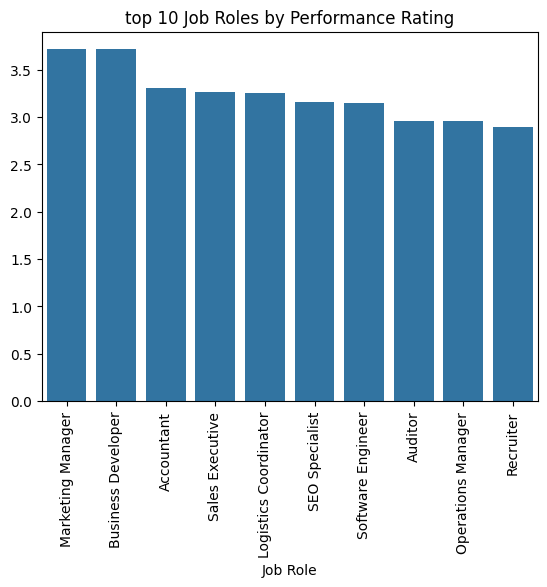

In [19]:
top_roles = df.groupby('Job Role')['Performance Rating'].mean().sort_values(ascending=False).head(10)
sb.barplot(x=top_roles.index, y=top_roles.values)
plt.xticks(rotation=90)
plt.title("top 10 Job Roles by Performance Rating")


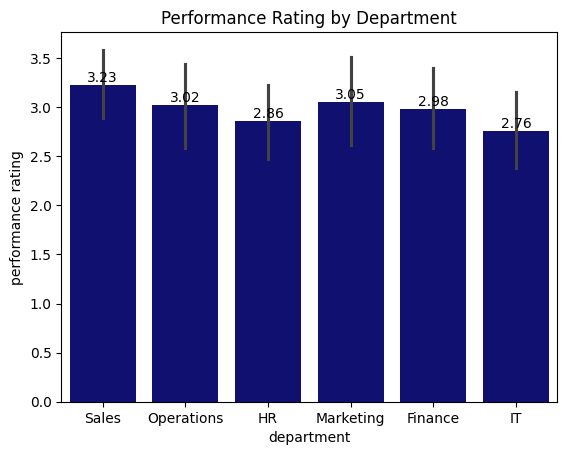

In [20]:
sb.barplot(df,x='Department',y='Performance Rating',color='Navy')
plt.title("Performance Rating by Department")
plt.bar_label(plt.gca().containers[0],fmt='%.2f')
plt.xlabel("department")
plt.ylabel("performance rating")
plt.show()

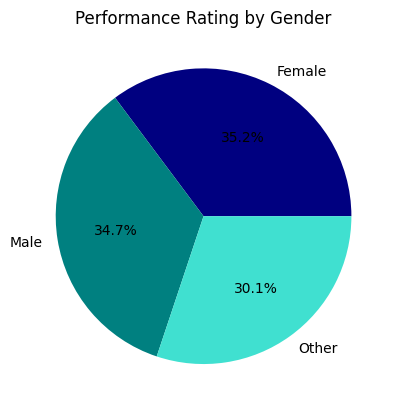

In [21]:
rating_by_gender=df.groupby('Gender')['Performance Rating'].mean()
col=['Navy', 'Teal', 'Turquoise']
plt.Figure(figsize=(8,6))
plt.pie(rating_by_gender,labels=rating_by_gender.index,autopct='%1.1f%%',colors=col)
plt.title('Performance Rating by Gender')
plt.show()

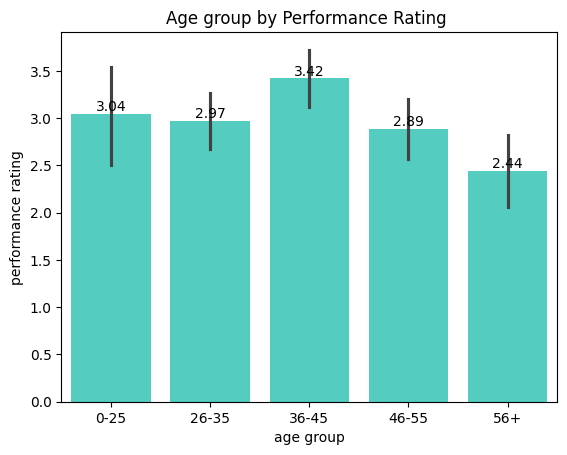

In [22]:
sb.barplot(df,x='Age_group',y='Performance Rating',color='Turquoise')
plt.title("Age group by Performance Rating ")
plt.bar_label(plt.gca().containers[0],fmt='%.2f')
plt.xlabel("age group")
plt.ylabel("performance rating")
plt.show()

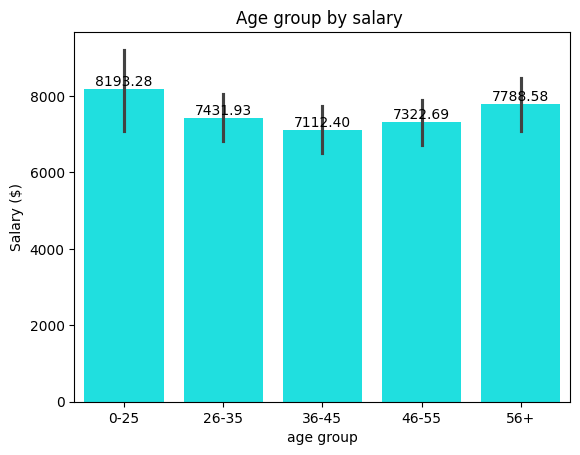

In [23]:
sb.barplot(df,x='Age_group',y='Salary ($)',color='Aqua')
plt.title("Age group by salary ")
plt.bar_label(plt.gca().containers[0],fmt='%.2f')
plt.xlabel("age group")
plt.ylabel("Salary ($)")
plt.show()

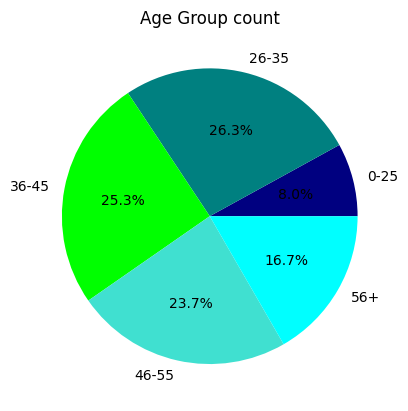

In [24]:
Age_group_count=df.groupby('Age_group')['Employee ID'].nunique()
col=['Navy', 'Teal','Lime', 'Turquoise','Aqua']
plt.Figure(figsize=(8,6))
plt.pie(Age_group_count,labels=Age_group_count.index,autopct='%1.1f%%',colors=col)
plt.title('Age Group count')
plt.show()

In [27]:
df.columns

Index(['Employee ID', 'Employee Name', 'Department', 'Job Role',
       'Joining Date', 'Experience (Years)', 'Age', 'Gender', 'Work Location',
       'Working Hours (Per Week)', 'Performance Rating', 'Salary ($)',
       'Bonus ($)', 'Training Hours (Per Year)', 'Job Satisfaction Score',
       'Leave Days Taken', 'Remote Work (%)', 'Promotion Status', 'Age_group',
       'Remote_Work(%)_Group', 'satisfication_category', 'Training_norm',
       'Productivity_Score'],
      dtype='str')

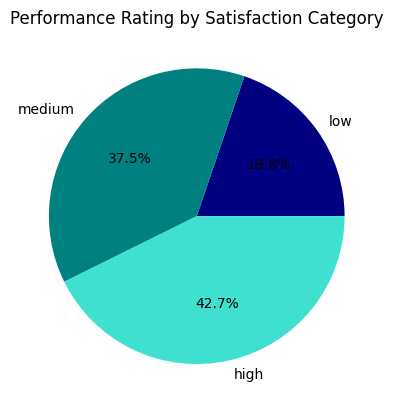

In [28]:
Performance_Rating_by_Satisfaction_Category=df.groupby('satisfication_category')['Performance Rating'].sum()
col=['Navy', 'Teal', 'Turquoise']
plt.Figure(figsize=(8,6))
plt.pie(Performance_Rating_by_Satisfaction_Category,labels=Performance_Rating_by_Satisfaction_Category.index,autopct='%1.1f%%',colors=col)
plt.title('Performance Rating by Satisfaction Category')
plt.show()

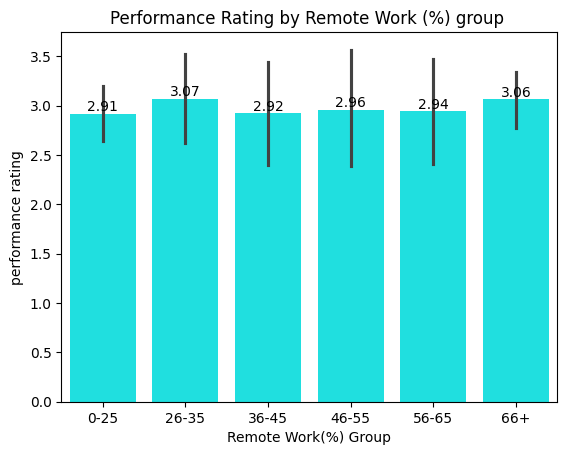

In [ ]:
sb.barplot(df,x='Remote_Work(%)_Group',y='Performance Rating',color='Cyan')
plt.title("Performance Rating by Remote Work (%) group ")
plt.bar_label(plt.gca().containers[0],fmt='%.2f')
plt.xlabel("Remote Work(%) Group")
plt.ylabel("performance rating")
plt.show()

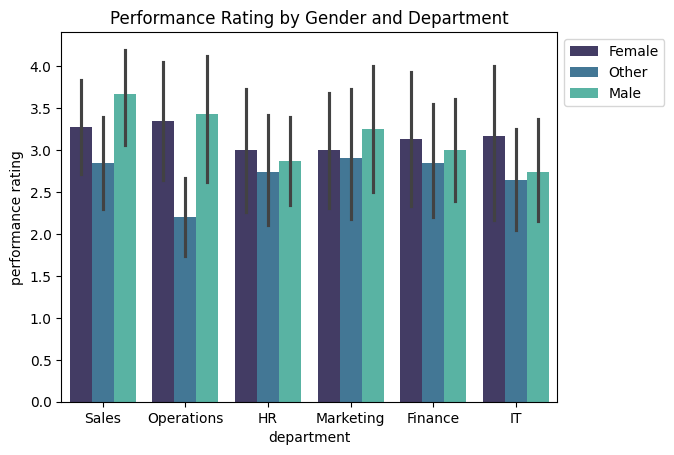

In [ ]:
sb.barplot(df,x='Department',y='Performance Rating',hue='Gender',palette='mako')
plt.title("Performance Rating by Gender and Department")
plt.xlabel("department")
plt.ylabel("performance rating")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

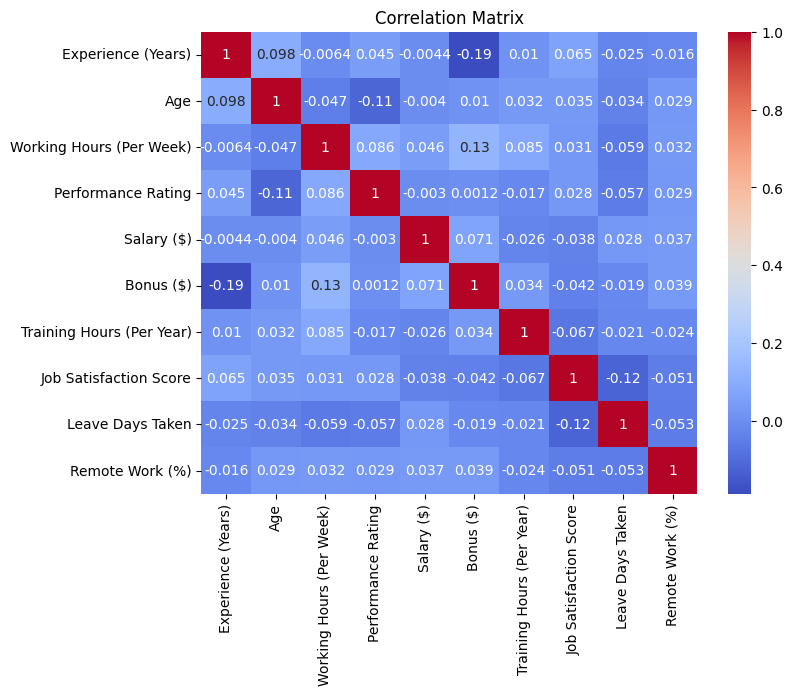

In [ ]:
plt.figure(figsize=(8,6))
sb.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Text(0.5, 1.0, 'Salary vs Performance')

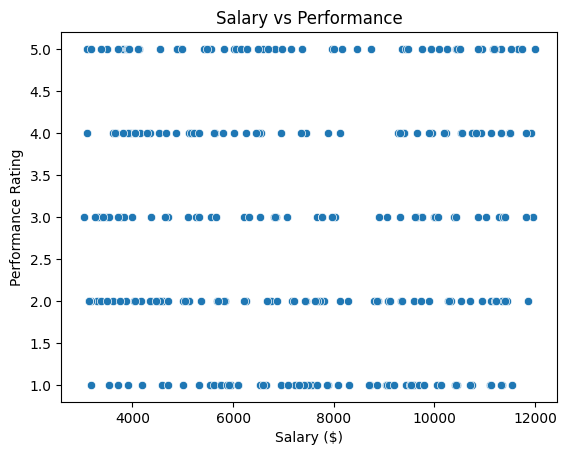

In [ ]:
sb.scatterplot(data=df, x='Salary ($)', y='Performance Rating')
plt.title("Salary vs Performance")

<Axes: xlabel='Experience (Years)', ylabel='Performance Rating'>

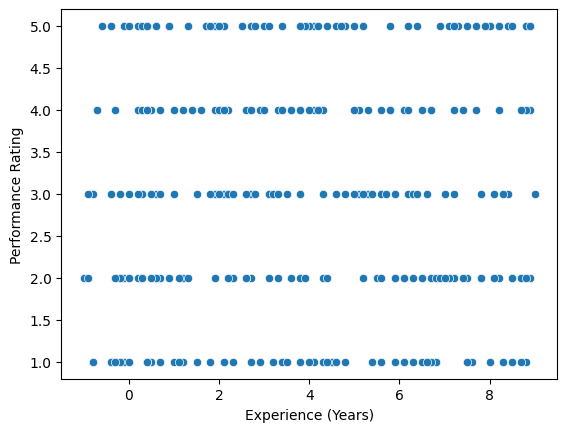

In [ ]:
sb.scatterplot(data=df, x='Experience (Years)', y='Performance Rating')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Sales'),
  Text(1, 0, 'Operations'),
  Text(2, 0, 'HR'),
  Text(3, 0, 'Marketing'),
  Text(4, 0, 'Finance'),
  Text(5, 0, 'IT')])

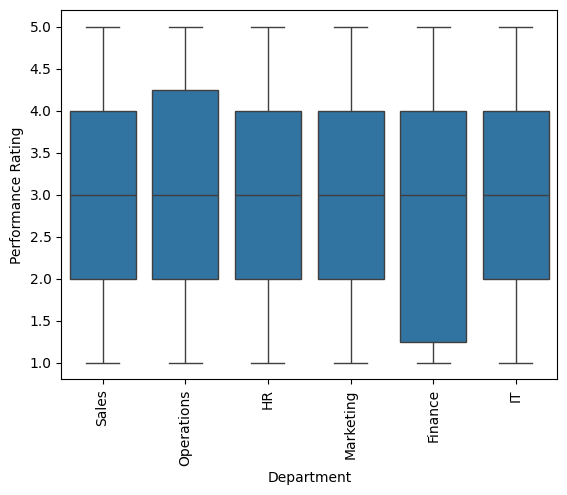

In [ ]:
sb.boxplot(data=df, x='Department', y='Performance Rating')
plt.xticks(rotation=90)

Text(0.5, 1.0, 'Training vs Performance')

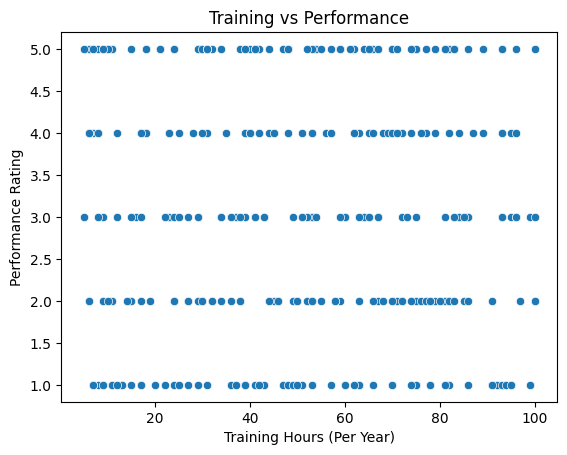

In [ ]:
sb.scatterplot(data=df, x='Training Hours (Per Year)', y='Performance Rating')
plt.title("Training vs Performance")

<Axes: xlabel='Experience_group', ylabel='Performance Rating'>

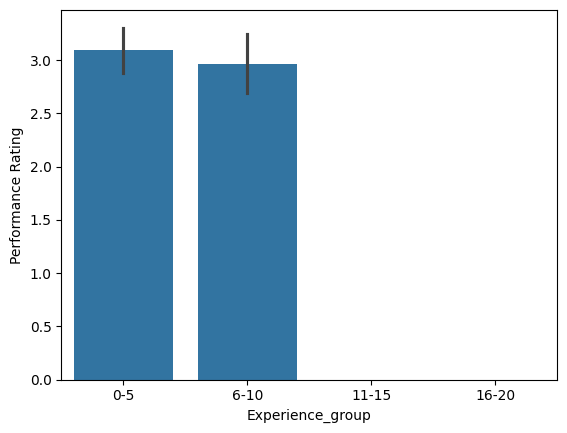

In [ ]:
df['Experience_group'] = pd.cut(df['Experience (Years)'],
                               bins=[0,5,10,15,20],
                               labels=['0-5','6-10','11-15','16-20'])

sb.barplot(data=df, x='Experience_group', y='Performance Rating')

# productivity analysis

In [26]:
# Normalize Training Hours
df['Training_norm'] = df['Training Hours (Per Year)'] / df['Training Hours (Per Year)'].max()

# Create Productivity Score
df['Productivity_Score'] = (
    df['Performance Rating'] * 0.5 +
    df['Job Satisfaction Score'] * 0.3 +
    df['Training_norm'] * 0.2
)

df[['Performance Rating','Job Satisfaction Score','Training Hours (Per Year)','Productivity_Score']].head()

,Performance Rating,Job Satisfaction Score,Training Hours (Per Year),Productivity_Score
0,3,3,34,2.468
1,2,7,59,3.218
2,2,1,80,1.460
3,3,2,84,2.268
4,5,4,70,3.840


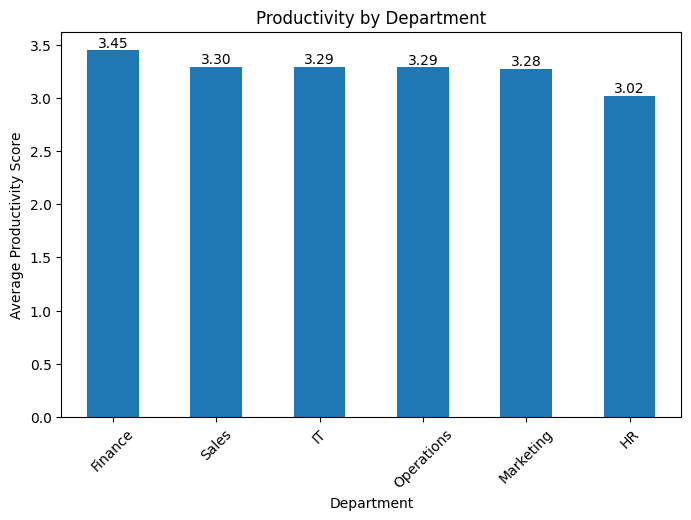

In [38]:
prod_dept = df.groupby('Department')['Productivity_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
prod_dept.plot(kind='bar')
plt.title("Productivity by Department")
plt.ylabel("Average Productivity Score")
plt.bar_label(plt.gca().containers[0],fmt='%.2f')
plt.xticks(rotation=45)
plt.show()

In [30]:
df.groupby('Gender')['Productivity_Score'].mean()

Gender
Female    3.353770
Male      3.311870
Other     3.157543
Name: Productivity_Score, dtype: float64

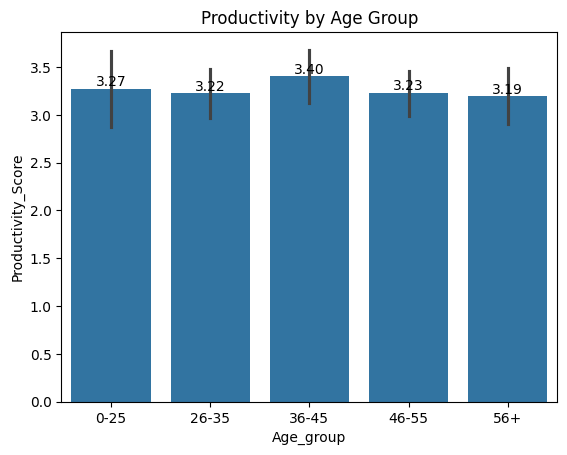

In [39]:
sb.barplot(data=df, x='Age_group', y='Productivity_Score')
plt.title("Productivity by Age Group")
plt.bar_label(plt.gca().containers[0],fmt='%.2f')
plt.show()

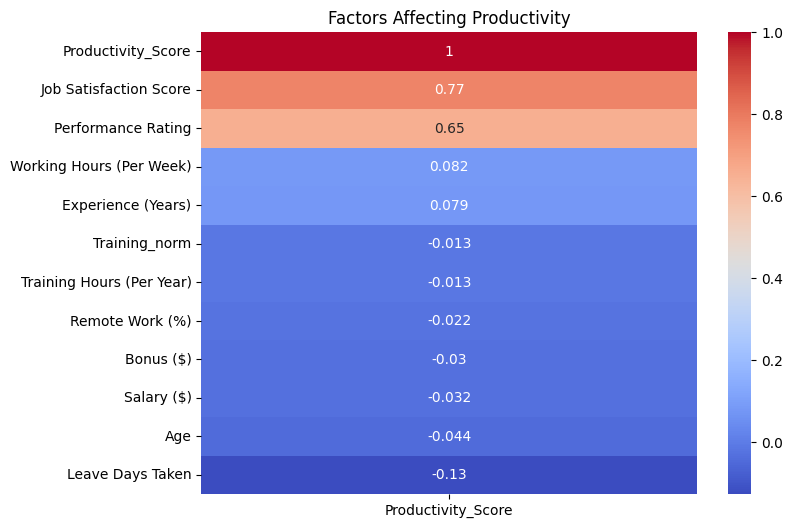

In [32]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sb.heatmap(corr[['Productivity_Score']].sort_values(by='Productivity_Score', ascending=False),
           annot=True, cmap='coolwarm')
plt.title("Factors Affecting Productivity")
plt.show()

In [41]:
df.columns

Index(['Employee ID', 'Employee Name', 'Department', 'Job Role',
       'Joining Date', 'Experience (Years)', 'Age', 'Gender', 'Work Location',
       'Working Hours (Per Week)', 'Performance Rating', 'Salary ($)',
       'Bonus ($)', 'Training Hours (Per Year)', 'Job Satisfaction Score',
       'Leave Days Taken', 'Remote Work (%)', 'Promotion Status', 'Age_group',
       'Remote_Work(%)_Group', 'satisfication_category', 'Training_norm',
       'Productivity_Score', 'Productivity_Level'],
      dtype='str')

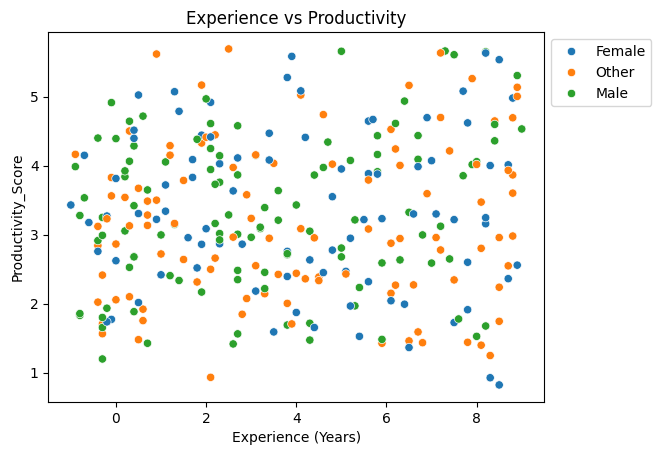

In [43]:
sb.scatterplot(data=df, x='Experience (Years)', y='Productivity_Score',hue="Gender")
plt.title("Experience vs Productivity")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

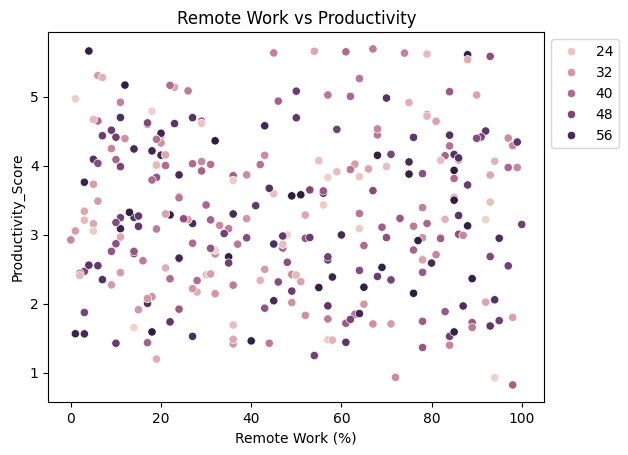

In [44]:
from matplotlib.patches import bbox_artist


sb.scatterplot(data=df, x='Remote Work (%)', y='Productivity_Score',hue='Age')
plt.title("Remote Work vs Productivity")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

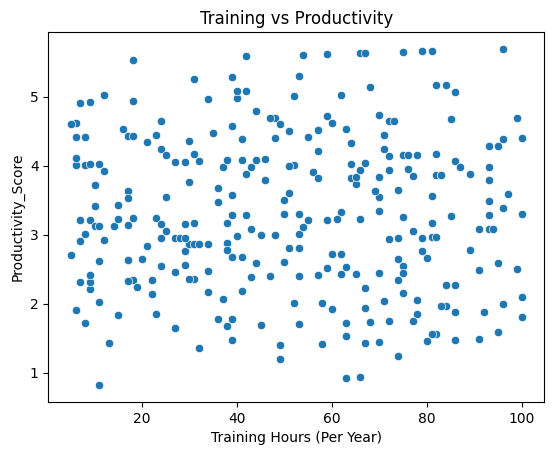

In [45]:
sb.scatterplot(data=df, x='Training Hours (Per Year)', y='Productivity_Score')
plt.title("Training vs Productivity")
plt.show()

In [51]:
top_emp = df.sort_values(by='Productivity_Score', ascending=False).head(10)
low_emp = df.sort_values(by='Productivity_Score').head(10)

top_emp[['Employee ID','Productivity_Score']]


,Employee ID,Productivity_Score
133,EMP0134,5.692
272,EMP0273,5.662
277,EMP0278,5.658
146,EMP0147,5.650
298,EMP0299,5.634
151,EMP0152,5.632
297,EMP0298,5.618
39,EMP0040,5.608
217,EMP0218,5.584
292,EMP0293,5.536


In [52]:
low_emp[['Employee ID','Productivity_Score']]

,Employee ID,Productivity_Score
212,EMP0213,0.822
116,EMP0117,0.926
260,EMP0261,0.932
271,EMP0272,1.198
288,EMP0289,1.248
237,EMP0238,1.364
202,EMP0203,1.398
53,EMP0054,1.416
131,EMP0132,1.426
246,EMP0247,1.426


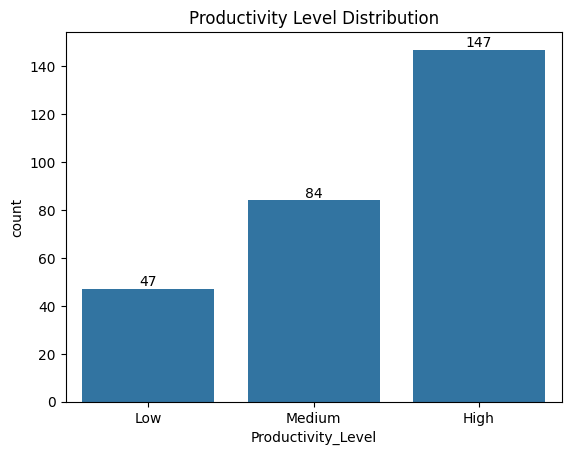

In [53]:
df['Productivity_Level'] = pd.cut(df['Productivity_Score'],
                                 bins=[0,2,3,5],
                                 labels=['Low','Medium','High'])

sb.countplot(data=df, x='Productivity_Level')
plt.title("Productivity Level Distribution")
plt.bar_label(plt.gca().containers[0])
plt.show()